## IMPORTING LIBRARIES ##

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import joblib

In [17]:
# data loading
crop = pd.read_csv("data/crop_yield.csv")
soil = pd.read_csv("data/soil_data.csv")
weather = pd.read_csv("data/weather_data.csv")

print(crop.head())
print(soil.head())
print(weather.head())

           crop  year       season  state     area  production  fertilizer  \
0      Arecanut  1997  Whole Year   Assam  73814.0       56708  7024878.38   
1     Arhar/Tur  1997  Kharif       Assam   6637.0        4685   631643.29   
2   Castor seed  1997  Kharif       Assam    796.0          22    75755.32   
3      Coconut   1997  Whole Year   Assam  19656.0   126905000  1870661.52   
4  Cotton(lint)  1997  Kharif       Assam   1739.0         794   165500.63   

   pesticide        yield  
0   22882.34     0.796087  
1    2057.47     0.710435  
2     246.76     0.238333  
3    6093.36  5238.051739  
4     539.09     0.420909  
               state   N   P   K   pH
0     Andhra Pradesh  78  45  22  6.8
1  Arunachal Pradesh  55  15  35  5.5
2              Assam  60  18  38  5.8
3              Bihar  85  30  25  7.2
4       Chhattisgarh  70  35  20  6.5
            state  year  avg_temp_c  total_rainfall_mm  avg_humidity_percent
0  Andhra Pradesh  1997       28.21            1191.08    

In [21]:
# data merging
columns = crop.columns.str.lower()
soil.columns = soil.columns.str.lower()
weather.columns = weather.columns.str.lower()

data = pd.merge(crop, weather, on=["state", "year"], how="left")
data = pd.merge(data, soil, on="state", how="left")

print(data.shape)

(19689, 16)


In [22]:
# NDVI & EVI (simulated)
data["ndvi"] = np.random.uniform(0.2, 0.9, len(data))
data["evi"] = np.random.uniform(0.1, 0.8, len(data))

# GDD
data["gdd"] = data["avg_temp_c"] - 10
data["gdd"] = data["gdd"].apply(lambda x: max(x, 0))

# Rainfall variability
data["rainfall_var"] = data.groupby("state")["total_rainfall_mm"].transform("std")

In [23]:
# data cleaning
data = data.drop(columns=["season", "area", "production"])
data = data.dropna()

le_crop = LabelEncoder()
le_state = LabelEncoder()

data["crop"] = le_crop.fit_transform(data["crop"])
data["state"] = le_state.fit_transform(data["state"])

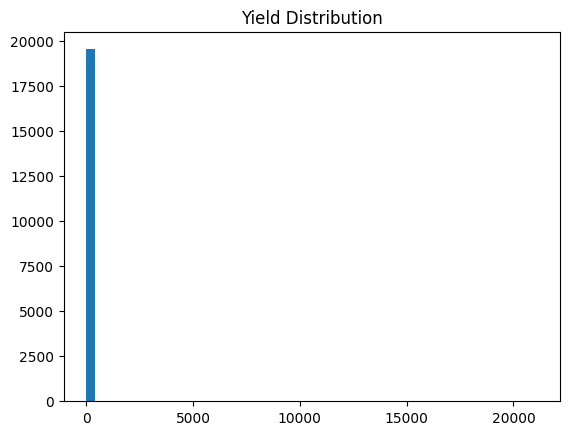

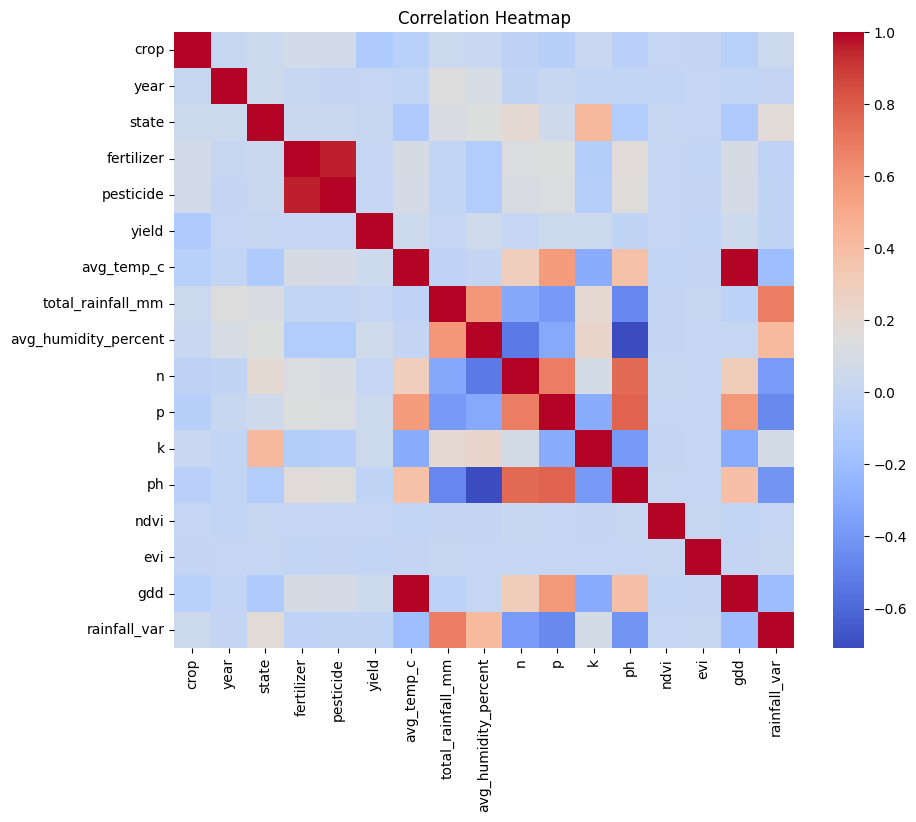

In [24]:
# Yield distribution
plt.hist(data["yield"], bins=50)
plt.title("Yield Distribution")
plt.show()

# Correlation heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
#Train-test split
X = data.drop(columns=["yield"])
y = data["yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Model training and evaluation
models = {
    "Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2", "MAE", "RMSE"])
results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)

               Model        R2         MAE        RMSE
2      Random Forest  0.973545   10.636907  145.590108
1      Decision Tree  0.967420   10.990425  161.569045
5  Gradient Boosting  0.961846   20.302895  174.843126
0             Linear  0.019345  196.855334  886.419705
3                SVR -0.007610   78.610632  898.519502
4                KNN -0.176204  157.255947  970.784033


In [27]:
# cross-validation for the best model
best_model = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(best_model, X, y, cv=5, scoring="r2")

print("CV Scores:", scores)
print("Average R2:", scores.mean())

CV Scores: [0.96603795 0.96019671 0.9951004  0.92808044 0.97781628]
Average R2: 0.965446353375232


                 Feature  Importance
0                   crop    0.841879
8                      n    0.105167
3             fertilizer    0.012455
4              pesticide    0.010724
1                   year    0.006226
7   avg_humidity_percent    0.004763
6      total_rainfall_mm    0.003071
13                   evi    0.002939
14                   gdd    0.002857
10                     k    0.002433
5             avg_temp_c    0.002278
12                  ndvi    0.001787
15          rainfall_var    0.001615
11                    ph    0.001290
9                      p    0.000261
2                  state    0.000255


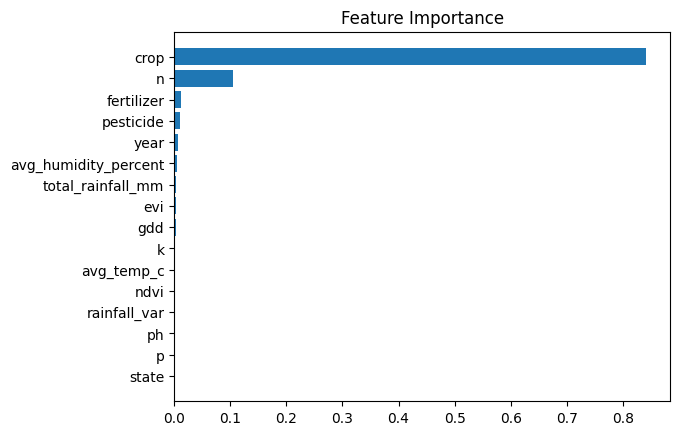

In [29]:
# feature eng
best_model.fit(X, y)

importance = best_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [36]:
# Save model and dataset
joblib.dump(best_model, "CropYieldProject/crop_yield_model.pkl")
data.to_csv("CropYieldProject/final_dataset.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'CropYieldProject/crop_yield_model.pkl'